# Global Submarine Internet Cable Network Map

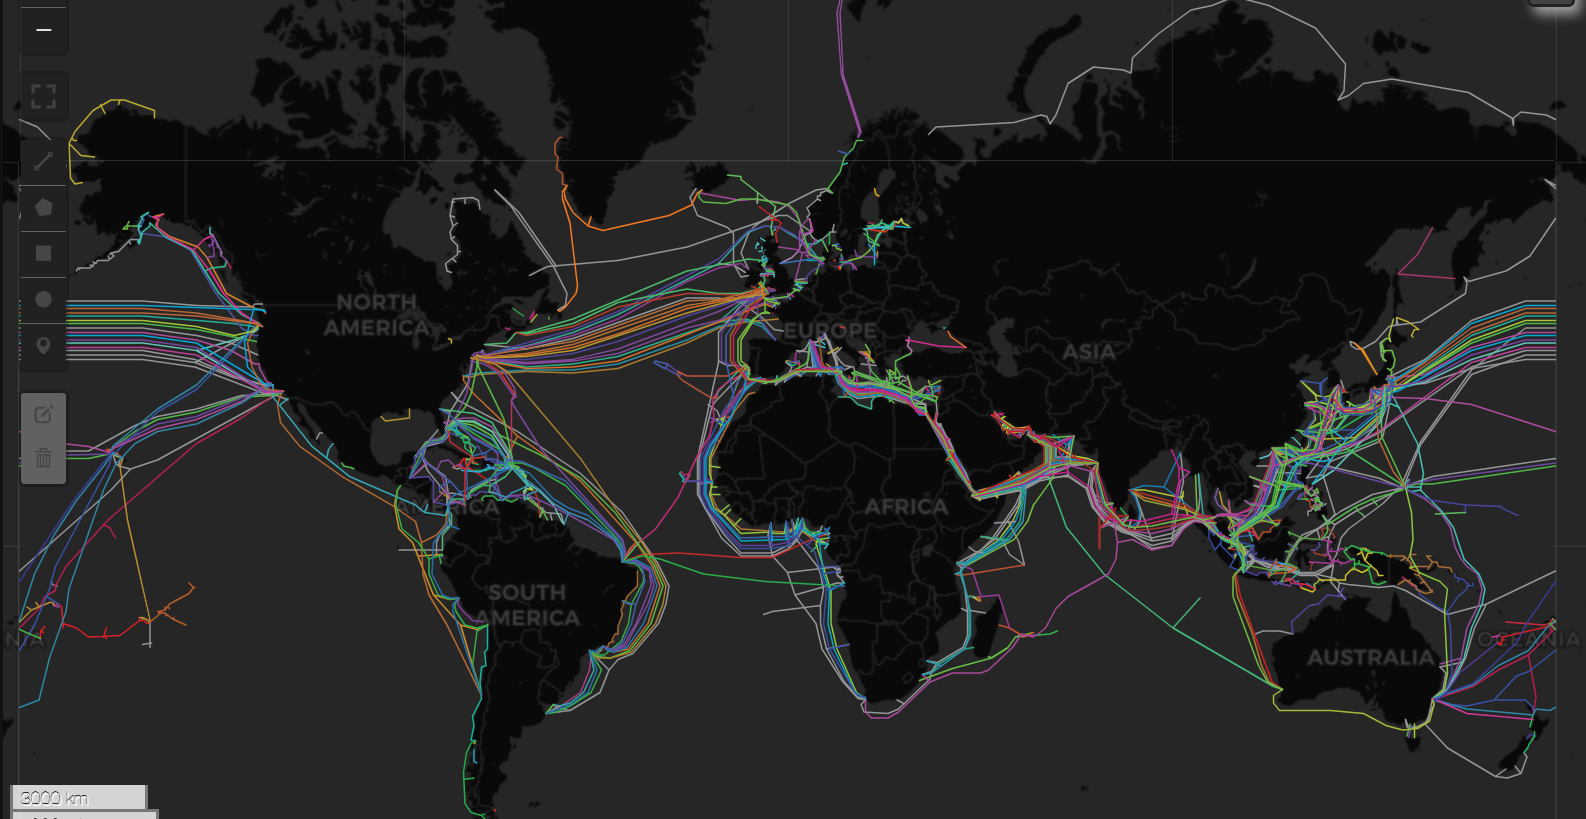

## Visualizing the world’s submarine internet cable network
Can you spot the most connected regions or cable hotspots from this map?

Overview
This project explores the global submarine internet cable network, which forms the backbone of international digital communication. For the first time, I utilized Python and leafmap to create an interactive, visually engaging map that demonstrates the connectivity and routing of submarine cables across continents and oceans.

The main objectives of the project are:

To visualize submarine cable networks on a global scale with interactivity.
To identify regions with high connectivity and potential vulnerability in internet infrastructure.
To create a reusable workflow for visualizing geospatial vector data with Python.
This project benefits researchers, network engineers, policy-makers, and students interested in digital infrastructure, network resilience, and geospatial visualization.

Using GeoPandas for geospatial data handling and leafmap (folium-based) for interactive mapping, the project transforms raw geojson cable data and global shapefiles into a map that is easy to explore, zoom, and understand.

 Methodology
Step	Description
1. Data Collection	Submarine cable dataset (cables_saved.geojson) and global country boundaries (World_Map.shp).
2. Preprocessing	Used GeoPandas to read the data and unify the CRS for spatial alignment.
3. Analysis	Mapped cable routes to understand global connectivity patterns; colored features based on cable characteristics.
4. Visualization	Created an interactive map using leafmap with basemap, world boundaries, cable layers, layer control, and map title.
5. Output	Exported the map as an interactive HTML file (submarine_cables_map.html) for easy sharing and exploration.


In [ ]:
# Install required packages
!pip install --quiet geopandas matplotlib leafmap

# Import to check
import geopandas as gpd
import matplotlib.pyplot as plt
import leafmap.foliumap as leafmap

print("All packages installed and imported successfully!")


All packages installed and imported successfully!


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import leafmap.foliumap as leafmap

In [ ]:
path = "/Users/satyamshah/Downloads/Global Internet Cable Spread/Data/cables_saved.geojson"
data = gpd.read_file(path)
data.head()

,id,name,color,feature_id,geometry
0,taiwan-penghu-kinmen-matsu-no-3-tpkm3,Taiwan Penghu Kinmen Matsu No.3 (TPKM3),#4dbd9a,taiwan-penghu-kinmen-matsu-no-3-tpkm3-0,"MULTILINESTRING ((119.93948 26.15145, 120.2624..."
1,unitirreno-cable,Unitirreno Cable,#939597,unitirreno-cable-0,"MULTILINESTRING ((10.91257 41.06934, 11.70007 ..."
2,kochi-lakshadweep-islands-cable,Kochi-Lakshadweep Islands Cable,#939597,kochi-lakshadweep-islands-cable-0,"MULTILINESTRING ((73.64411 10.06982, 73.91252 ..."
3,sagres,Sagres,#4ab970,sagres-0,"MULTILINESTRING ((-9.10275 38.44308, -8.99992 ..."
4,continente-madeira,Continente-Madeira,#37b98e,continente-madeira-0,"MULTILINESTRING ((-9.33156 38.69016, -10.79992..."


In [ ]:
world = gpd.read_file("/Users/satyamshah/Downloads/Global Internet Cable Spread/Data/World_Map.shp")
world.head()

,NAME,geometry
0,Antigua and Barbuda,"MULTIPOLYGON (((-61.68667 17.02444, -61.73806 ..."
1,Algeria,"POLYGON ((2.96361 36.80222, 2.98139 36.80694, ..."
2,Azerbaijan,"MULTIPOLYGON (((45.08332 39.76804, 45.26639 39..."
3,Albania,"POLYGON ((19.43621 41.02106, 19.45055 41.06, 1..."
4,Armenia,"MULTIPOLYGON (((45.57305 40.63249, 45.52888 40..."


In [ ]:
data = data.to_crs(world.crs)

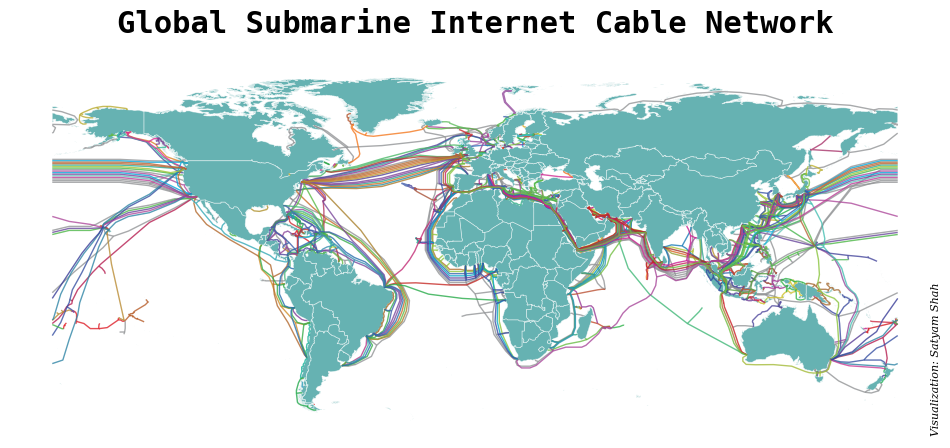

In [ ]:
fig, ax = plt.subplots(figsize=(12,7))

# 3Plot the Landmasses (World)
world.plot(ax=ax,
           color="teal",        # Dark, muted gray-blue for land
           edgecolor="white",       # Remove the black outlines for a cleaner look
           linewidth=0.5,
           alpha=0.6               # Slightly higher opacity
          )

data.plot(ax=ax,
          color=data['color'],  # Use the hex colors from the 'color' column
          linewidth=1,
          alpha=0.8,
          legend=True,             # Add a legend if using a color map (like 'plasma')
          legend_kwds={'label': "Cable Capacity/Year",
                       'orientation': "horizontal",
                       'shrink': 0.7,
                       'pad': 0.05} # Customize legend placement
         )

ax.axis("off")
ax.set_title("Global Submarine Internet Cable Network",
             fontdict={'fontsize': '22',
                       'fontweight': 'bold',
                       'color': 'black'},
             fontname='monospace', weight = 'semibold',
             loc='center',
             pad=20) # 'pad' adds space between the title and the plot

ax.text(x= .99, y= .01, s= "Visualization: Satyam Shah",
        fontname='serif', weight = 'normal',style='italic',
        rotation='vertical', transform=ax.transAxes, size=8
       )

plt.savefig("Global Submarine Internet Cable Network",
            dpi=300, bbox_inches= "tight"
           )
plt.show()

In [ ]:
leafmap.basemaps.keys()

dict_keys(['OpenStreetMap', 'ROADMAP', 'SATELLITE', 'TERRAIN', 'HYBRID', 'FWS NWI Wetlands', 'FWS NWI Wetlands Raster', 'NLCD 2021 CONUS Land Cover', 'NLCD 2019 CONUS Land Cover', 'NLCD 2016 CONUS Land Cover', 'NLCD 2013 CONUS Land Cover', 'NLCD 2011 CONUS Land Cover', 'NLCD 2008 CONUS Land Cover', 'NLCD 2006 CONUS Land Cover', 'NLCD 2004 CONUS Land Cover', 'NLCD 2001 CONUS Land Cover', 'USGS NAIP Imagery', 'USGS NAIP Imagery False Color', 'USGS NAIP Imagery NDVI', 'USGS Hydrography', 'USGS 3DEP Elevation', 'USGS 3DEP Elevation Index', 'ESA WorldCover 2020', 'ESA WorldCover 2020 S2 FCC', 'ESA WorldCover 2020 S2 TCC', 'ESA WorldCover 2021', 'ESA WorldCover 2021 S2 FCC', 'ESA WorldCover 2021 S2 TCC', 'USGS.Imagery', 'BasemapAT.basemap', 'BasemapAT.grau', 'BasemapAT.highdpi', 'BasemapAT.orthofoto', 'BasemapAT.overlay', 'BasemapAT.surface', 'BasemapAT.terrain', 'CartoDB.DarkMatter', 'CartoDB.DarkMatterNoLabels', 'CartoDB.DarkMatterOnlyLabels', 'CartoDB.Positron', 'CartoDB.PositronNoLabels'

In [ ]:
m = leafmap.Map(center = (20,0), zoom = 2,
                draw_control=False, measure_control=False)
m.add_basemap("CartoDB.DarkMatter")


style_func = lambda feat: {'color': feat['properties']['color'], 'weight': 1}
m.add_vector(path, layer_name='Submarine Cables', style_callback=style_func)

# Save to HTML for website
m.to_html("Global_Submarine_Cables_Map.html")

m

# Results & Insights
🔹 The Atlantic and Pacific routes show the densest cable networks.

🔹 Coastal regions of North America, Europe, and East Asia have the highest connectivity.

🔹 Some regions like Africa and South America are less connected, highlighting potential infrastructure gaps.

# Author: Satyam Shah

Portfolio : https://satyamspace.github.io/

Linkedin: https://www.linkedin.com/feed/